# BZ router_strategy analysis

Analysis of the BZ MiniMax-M2.7 multi-turn sweep (CodeFlowBench + Claude Code injection).
Six experiments, one per `router_strategy` (+ hard/soft affinity variants), same seed/workload:

| exp_id | router_strategy | affinity mode | meaning |
|--------|-----------------|---------------|---------|
| 23 | none | — | baseline (prefix off, affinity off) |
| 24 | prefix | — | KV prefix-awareness only |
| 25 | affinity | hard | conversation key-affinity (time-bounded pin) |
| 27 | affinity | soft | conversation key-affinity (preference only) |
| 26 | both | hard | prefix + affinity (pin) |
| 28 | both | soft | prefix + affinity (preference) |

All six ran with `collect_router_log=on` and `ROUTER_MEASURE_PREFIX=on`, so per-request
`endpoint_id`, `kv_hits_len`, `total_blocks`, `kv_hit`, `matched_tokens`, and `block_hashes`
come straight from `logs.json` for **every** strategy — including `none`/`affinity` where KV
routing is off but prefix reuse is still measured.

Experiments live under `/data/experiments` (BZ shared dir; `src/experiments` symlinks here).
Adjust `EXPERIMENTS` below to match the actual experiment IDs produced by your sweep.


In [1]:
# BZ experiment IDs -> router_strategy. DP1 x 4-node sweep (worker2 back/untainted).
# Sweep 23-28: full hard-vs-soft affinity comparison with collect_router_log=on AND
# ROUTER_MEASURE_PREFIX=on, so endpoint + prefix/KV + affinity_key come straight from
# logs.json (router_log_collector + end-of-run join) for EVERY strategy -- including
# none/affinity (KV routing off), which now report real prefix-hit counts.
EXPERIMENTS_ROOT = "/data/experiments"
STRATEGY_LABELS = {
    23: "none",
    24: "prefix",
    25: "affinity (hard)",
    26: "both (hard)",
    27: "affinity (soft)",
    28: "both (soft)",
}
EXPERIMENTS = list(STRATEGY_LABELS.keys())
print("experiments:", EXPERIMENTS, "->", [STRATEGY_LABELS[e] for e in EXPERIMENTS])


experiments: [23, 24, 25, 26, 27, 28] -> ['none', 'prefix', 'affinity (hard)', 'both (hard)', 'affinity (soft)', 'both (soft)']


## Latency Metrics

In [2]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=EXPERIMENTS[0], experiments_root="/data/experiments")
df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]]


,end_to_end_s
count,350.000000
mean,12.821540
std,4.702598
min,2.665682
50%,14.650356
90%,17.449750
99%,19.754026
max,20.948674


In [3]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,ttft_s,tpot_avg_s,streaming_chunks,streaming,endpoint_id,serving_pod,serving_node,applied_time_offset_s
0,<NA>,chatcmpl-afa8304325814ff883585cc44c73e4f9,False,3.983854,3.983785,length,25400,64,25464,1.757160,0.035340,66,True,vllm-minimax-m2-c7d5b98d8-77q4n,None,None,NaN
1,<NA>,chatcmpl-8a4be14df88747cbbaa51c14be9c9f9c,False,4.119725,4.119591,length,25501,64,25565,1.358415,0.043800,66,True,vllm-minimax-m2-c7d5b98d8-77q4n,None,None,NaN
2,<NA>,chatcmpl-8445ed645f17447bab6ebeedcf899fdb,False,4.965334,4.965268,length,25581,64,25645,0.959712,0.063558,66,True,vllm-minimax-m2-c7d5b98d8-62dc6,None,None,NaN
3,<NA>,chatcmpl-b97b8fee8de347f68d0b35131c90035a,False,5.983001,5.982927,length,25706,64,25770,1.558110,0.070216,66,True,vllm-minimax-m2-c7d5b98d8-62dc6,None,None,NaN
4,<NA>,chatcmpl-7058f31250f84e2ba784080fca3d2605,False,6.200083,6.200006,length,25386,64,25450,0.997894,0.082569,66,True,vllm-minimax-m2-c7d5b98d8-nw68l,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,<NA>,chatcmpl-36f2a00b8f2d4518a23a6753730ca88c,False,2.678370,2.678291,length,26293,64,26357,0.669739,0.031879,66,True,vllm-minimax-m2-c7d5b98d8-62dc6,None,None,NaN
346,<NA>,chatcmpl-795ca45859484e36a0b020534a5cbd3d,False,3.080009,3.079906,length,26291,64,26355,0.696579,0.037826,66,True,vllm-minimax-m2-c7d5b98d8-77q4n,None,None,NaN
347,<NA>,chatcmpl-47d3a6ca2eaa494795cf4ecbaf7dd7d0,False,2.749330,2.749251,length,26555,64,26619,0.674989,0.032922,66,True,vllm-minimax-m2-c7d5b98d8-77q4n,None,None,NaN
348,<NA>,chatcmpl-9095d6f606954c2db4268458beb9f6d6,False,2.931179,2.931103,length,26215,64,26279,0.674093,0.035823,66,True,vllm-minimax-m2-c7d5b98d8-nw68l,None,None,NaN


In [4]:
from experiment_analysis import experiments_from_series

In [5]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS

print(experiments)
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id, experiments_root="/data/experiments")

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison

series_ids = [35]

[23, 24, 25, 26, 27, 28]


[23, 24, 25, 26, 27, 28]
[exp 23] corrected_requests=0/350
[exp 24] corrected_requests=0/350
[exp 25] corrected_requests=0/350
[exp 26] corrected_requests=0/350
[exp 27] corrected_requests=0/350
[exp 28] corrected_requests=0/350

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 23:
  client_to_router_s          :      nan s
  router_queue_s              :      nan s
  router_to_sidecar_s         :      nan s
  sidecar_queue_s             :      nan s
  vllm_compute_s              :      nan s
  sidecar_post_s              :      nan s
  sidecar_to_router_s         :      nan s
  router_post_result_s        :      nan s
  SUM (components)            :    0.000 s

  Router post-result breakdown:
    router_result_handler_s   :      nan s
    router_wakeup_s           :      nan s
    router_response_build_s   :      nan s
    router_after_return_stamp_s:      nan s
    SUM (post breakdown)      : 0.000000 s

  end_to_end_s                :   12.822 s


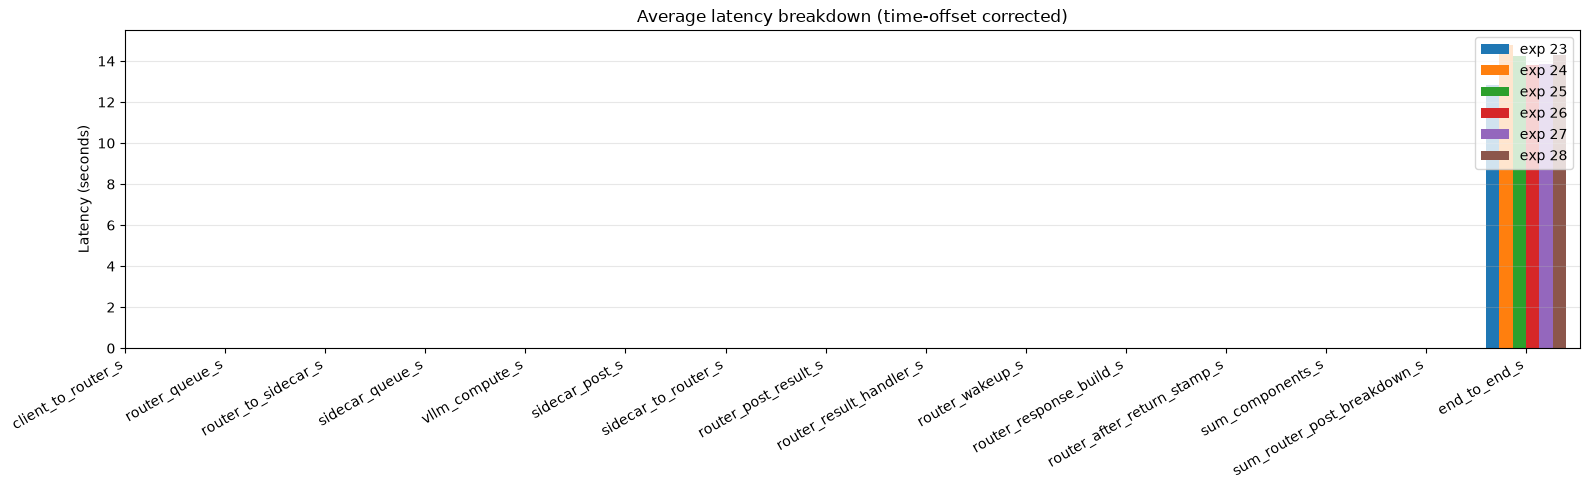

In [6]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS
print(experiments)
# ---------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]

# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]

extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]

e2e_col = "end_to_end_s"

plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)

avg_by_exp = {}

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
        experiments_root="/data/experiments"
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))

    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))

    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)

    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")

    row = {}

    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))

    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))

    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))

    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean

    avg_by_exp[exp_id] = row

# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")

for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")

    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")

    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()

    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")

    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()

    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()

# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))

plt.figure(figsize=(16, 5))

for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")

plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [27]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS
print(experiments)

# ----------------------------------------------

# Latency columns of interest
cols = [
    # "end_to_end_s",
    "ttft_s"
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/data/experiments")
    df = df.iloc[20:]
    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


[23, 24, 25, 26, 27, 28]


,exp23_ttft_s,exp24_ttft_s,exp25_ttft_s,exp26_ttft_s,exp27_ttft_s,exp28_ttft_s
count,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
mean,1.664584,1.851877,1.879044,1.713264,1.496106,1.662307
std,0.705447,0.932997,1.124533,0.753688,0.496559,0.757388
min,0.624192,0.642873,0.660485,0.662619,0.662171,0.633133
50%,1.495166,1.517421,1.556818,1.528983,1.424967,1.497171
90%,2.803867,3.218927,3.310262,2.866141,2.196709,2.804910
99%,3.506228,4.484723,6.928378,3.732825,2.638086,3.804037
max,3.753181,4.951624,7.218546,3.988672,3.107060,4.442606


In [8]:
# from experiment_analysis import load_experiment_latencies
# import pandas as pd
# # ---- choose experiments (exclude first 20 entries) ----
# # choose which series you want
# # series_ids = [35]
# # experiments = experiments_from_series(series_ids)
# experiments = EXPERIMENTS
# print(experiments)
# # ----------------------------------------------
# # Latency columns of interest
# cols = [
#     "end_to_end_s",
#     # "server_roundtrip_s",
#     # "router_queue_s",
#     # "vllm_compute_s",
# ]
# percentiles = [0.5, 0.9, 0.99]
# summaries = []
# for exp_id in experiments:
#     df = load_experiment_latencies(exp_id=exp_id)
#     df = df.iloc[20:]
#     summary = (
#         df.describe(percentiles=percentiles)[cols]
#           .add_prefix(f"exp{exp_id}_")
#     )
#     summaries.append(summary)
# # Combine all experiments side-by-side
# comparison = pd.concat(summaries, axis=1)
# comparison


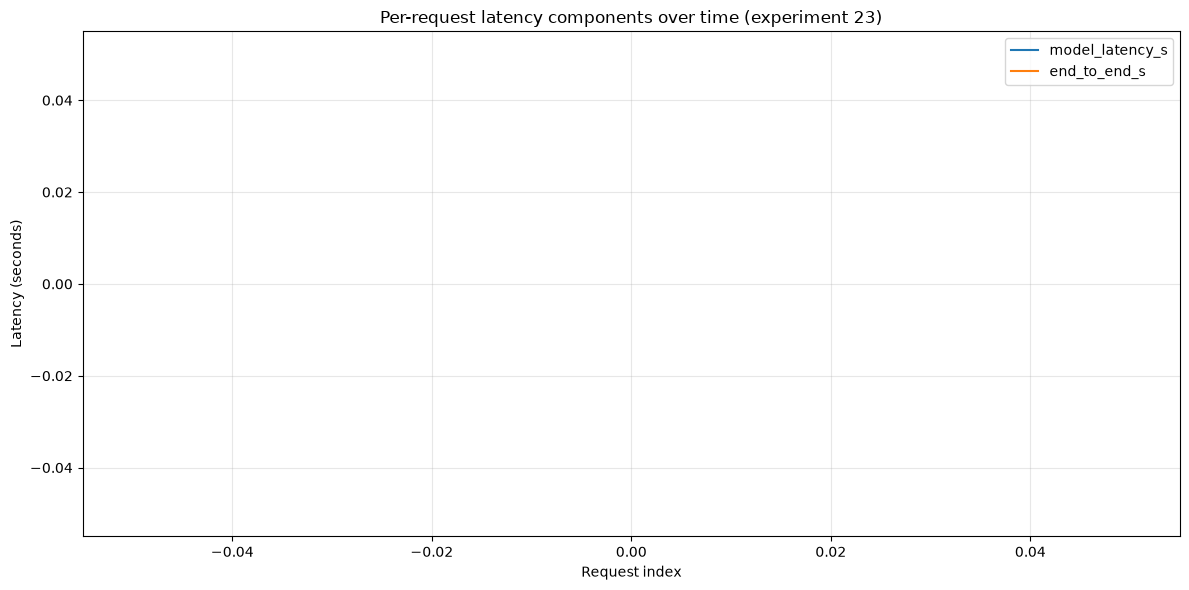

In [9]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = EXPERIMENTS[0]
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(
    exp_id=exp_id,
    experiments_root="/data/experiments").sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[23, 24, 25, 26, 27, 28]
[exp 23] corrected_requests=0/350
[exp 24] corrected_requests=0/350
[exp 25] corrected_requests=0/350
[exp 26] corrected_requests=0/350
[exp 27] corrected_requests=0/350
[exp 28] corrected_requests=0/350


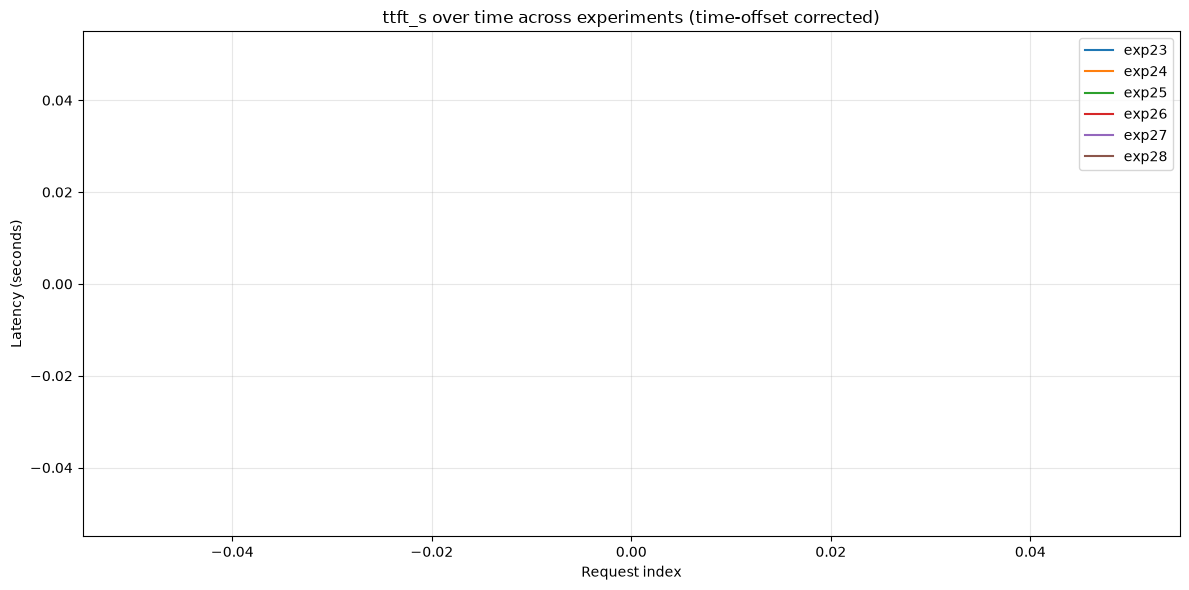

In [10]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS

print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/data/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Throughput Metrics

In [11]:
# Split the sum and mean group based on metric characteristics.
# SLO violation for TTFT and TPOT, can be customised based on the target SLO. For Qwen3-8B model, assume the SLO for TTFT is 500ms, for TPOT is 50 ms

from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS
print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)

# aggregated by SUM across instances per tick
sum_cols = [
    "gen_tokens_per_sec",
    # "prefill_tokens_per_sec",
    # "requests_running",       # sum = cluster total queue depth; use mean if single-instance or want per-instance avg
    # "requests_waiting",       # same as above
    # "request_success_per_sec",
    # "preemptions_per_sec",
    # --- prefix cache rates (sum across instances) ---
    # "prefix_cache_hits_per_sec",
    # "prefix_cache_queries_per_sec",
    # "ext_prefix_cache_hits_per_sec",
    # "ext_prefix_cache_queries_per_sec",
    # "prompt_tokens_cached_per_sec",
]

# aggregated by MEAN across instances per tick
# (these are pre-averaged histograms inside vLLM)
mean_cols = [
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    # "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",

    # # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",

    # # spec decode (optional)
    # "spec_tokens_accepted_per_sec",  # debatable: could be sum if you want cluster total
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",
    # "kv_cache_usage_perc",           # GPU KV cache usage (%)
    # "prefix_cache_hit_rate",         # derived: hits / queries
    # "ext_prefix_cache_hit_rate",     # derived: ext hits / ext queries
]

percentiles = [0.5, 0.9, 0.99]

# SLO thresholds
TTFT_SLO_S = 0.500  # 500ms in seconds
TPOT_SLO_S = 0.050  # 50ms in seconds

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/data/experiments")
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    valid_sum_cols  = [c for c in sum_cols  if c in prom.columns]
    valid_mean_cols = [c for c in mean_cols if c in prom.columns]

    missing = set(sum_cols + mean_cols) - set(prom.columns)
    if missing:
        print(f"[WARN] exp{exp_id}: columns not found in prom, skipping: {missing}")

    agg_sum  = prom.groupby("ts")[valid_sum_cols].sum(min_count=1).reset_index()
    agg_mean = prom.groupby("ts")[valid_mean_cols].mean().reset_index()
    agg = agg_sum.merge(agg_mean, on="ts", how="outer")

    # Describe only the columns that actually exist in agg
    valid_all_cols = [c for c in (sum_cols + mean_cols) if c in agg.columns]
    summary = (
        agg[valid_all_cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )

    # ---- SLO compliance: % of ticks where metric is within SLO ----
    # NaN ticks (no completed requests) are excluded from both numerator and denominator
    if "ttft_seconds_avg" in agg.columns:
        ttft_col = agg["ttft_seconds_avg"].dropna()
        ttft_slo_pct = (ttft_col <= TTFT_SLO_S).mean() * 100
    else:
        ttft_slo_pct = float("nan")

    if "tpot_seconds_avg" in agg.columns:
        tpot_col = agg["tpot_seconds_avg"].dropna()
        tpot_slo_pct = (tpot_col <= TPOT_SLO_S).mean() * 100
    else:
        tpot_slo_pct = float("nan")

    # Build SLO row — NaN for all cols without a defined SLO
    slo_data = {f"exp{exp_id}_{c}": float("nan") for c in valid_all_cols}
    slo_data[f"exp{exp_id}_ttft_seconds_avg"] = ttft_slo_pct
    slo_data[f"exp{exp_id}_tpot_seconds_avg"] = tpot_slo_pct
    slo_row = pd.DataFrame(slo_data, index=["SLO_COMPLIANCE_%"])

    summary = pd.concat([summary, slo_row])
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[23, 24, 25, 26, 27, 28]


,exp23_gen_tokens_per_sec,exp23_ttft_seconds_avg,exp23_tpot_seconds_avg,exp24_gen_tokens_per_sec,exp24_ttft_seconds_avg,exp24_tpot_seconds_avg,exp25_gen_tokens_per_sec,exp25_ttft_seconds_avg,exp25_tpot_seconds_avg,exp26_gen_tokens_per_sec,exp26_ttft_seconds_avg,exp26_tpot_seconds_avg,exp27_gen_tokens_per_sec,exp27_ttft_seconds_avg,exp27_tpot_seconds_avg,exp28_gen_tokens_per_sec,exp28_ttft_seconds_avg,exp28_tpot_seconds_avg
count,55.000000,53.000000,NaN,61.000000,59.000000,NaN,61.000000,59.000000,NaN,59.000000,57.000000,NaN,58.000000,56.000000,NaN,59.000000,57.000000,NaN
mean,328.454986,0.632036,NaN,301.757385,0.621949,NaN,292.043833,0.606548,NaN,319.627497,0.596138,NaN,305.014732,0.618155,NaN,297.215072,0.616717,NaN
std,137.172945,0.125991,NaN,106.636283,0.129170,NaN,132.930841,0.141043,NaN,142.495159,0.151200,NaN,105.944452,0.104416,NaN,108.939336,0.121127,NaN
min,0.000000,0.438290,NaN,0.000000,0.459058,NaN,0.000000,0.435948,NaN,0.000000,0.444046,NaN,0.000000,0.450679,NaN,0.000000,0.453171,NaN
50%,341.000000,0.616328,NaN,319.500000,0.599462,NaN,297.500000,0.567991,NaN,330.000000,0.561724,NaN,308.750000,0.610598,NaN,307.500000,0.606365,NaN
90%,455.000000,0.759502,NaN,418.500000,0.738659,NaN,461.000000,0.749472,NaN,490.197196,0.736997,NaN,421.700000,0.722906,NaN,419.100000,0.714766,NaN
99%,659.800592,1.043309,NaN,491.100000,1.091066,NaN,550.200000,1.102926,NaN,634.950000,1.177510,NaN,504.365000,0.981952,NaN,467.310000,1.096237,NaN
max,667.500000,1.109873,NaN,502.500000,1.306928,NaN,580.500000,1.298871,NaN,706.000000,1.316263,NaN,507.500000,1.075459,NaN,470.500000,1.157317,NaN
SLO_COMPLIANCE_%,NaN,9.433962,NaN,NaN,5.084746,NaN,NaN,10.169492,NaN,NaN,22.807018,NaN,NaN,5.357143,NaN,NaN,10.526316,NaN


[23, 24, 25, 26, 27, 28]


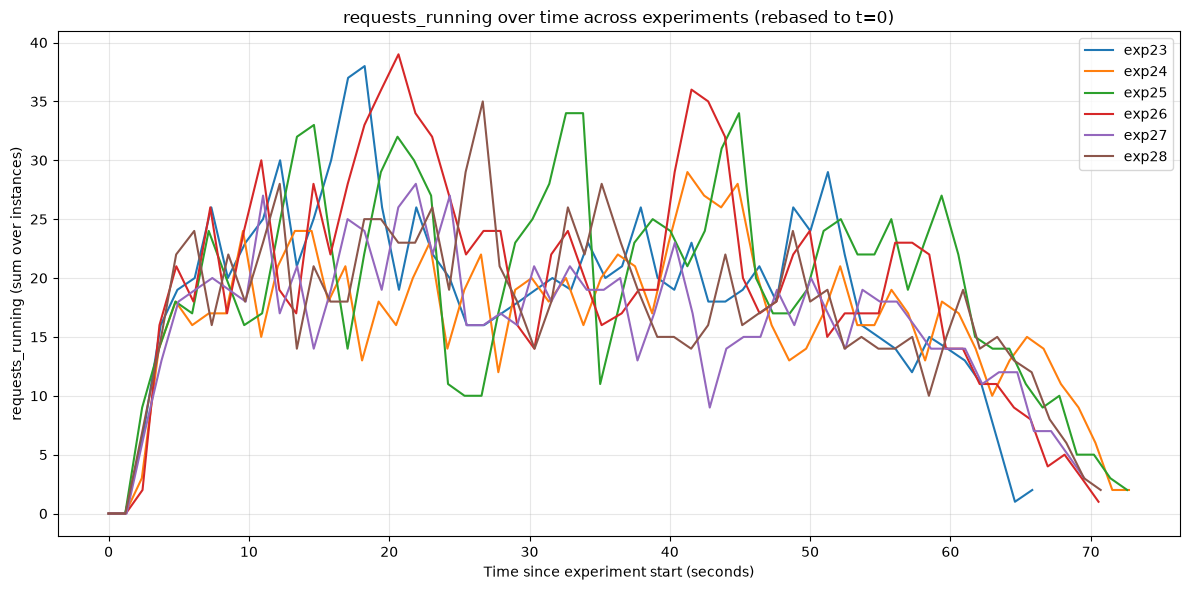

In [12]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
# --- router histogram percentiles ---
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/data/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

[23, 24, 25, 26, 27, 28]


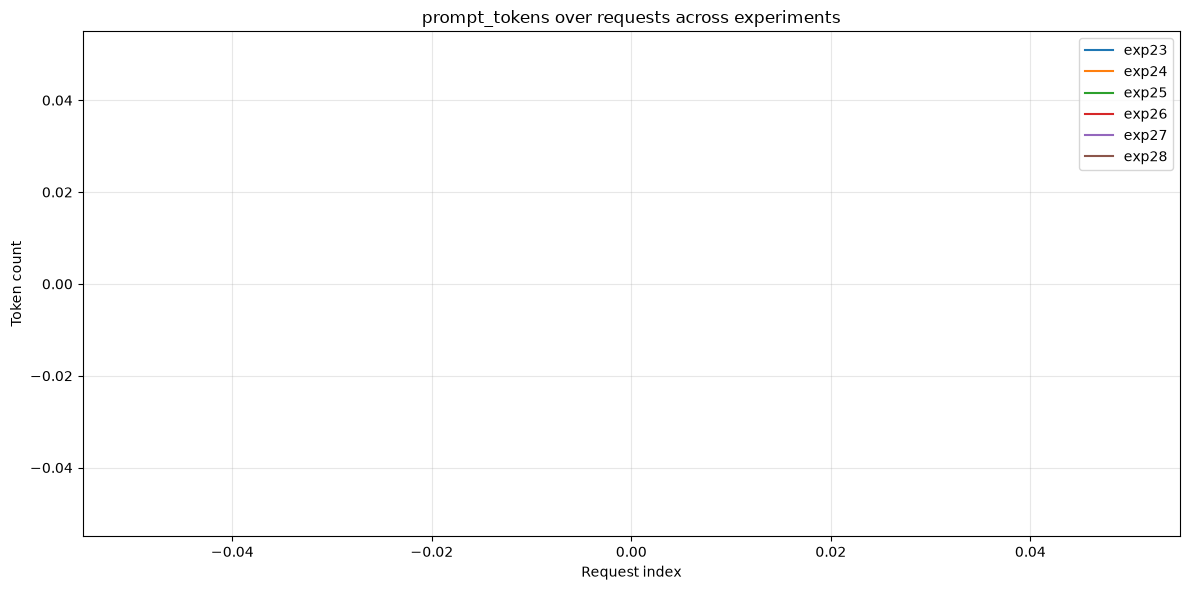

In [13]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
# metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            experiments_root="/data/experiments")
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [14]:
from experiment_analysis import load_experiment_latencies

experiments = EXPERIMENTS

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/data/experiments")
    total = df["total_tokens"].sum()
    print(f"exp{exp_id}: {total} total tokens")

exp23: 9023970 total tokens
exp24: 9023808 total tokens
exp25: 9023649 total tokens
exp26: 9023696 total tokens
exp27: 9023298 total tokens
exp28: 9023649 total tokens


[23, 24, 25, 26, 27, 28]


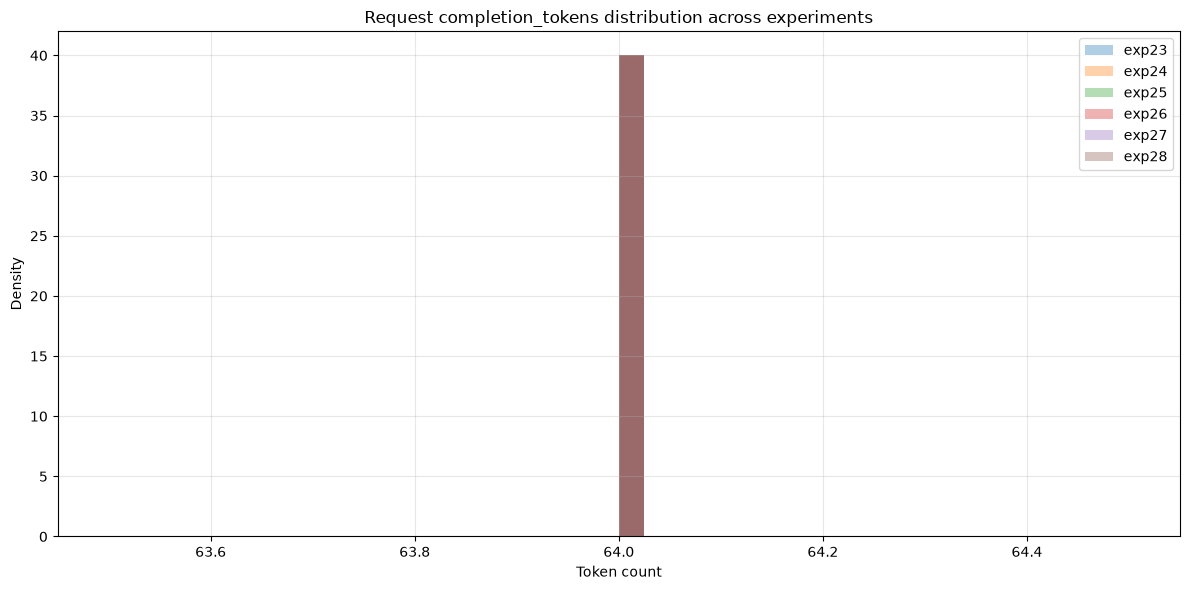

In [15]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
metric = "completion_tokens"  # output length distribution
# metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
    experiments_root="/data/experiments")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [16]:
from pathlib import Path
import json
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS

print(experiments)
# ----------------------------


def count_requests(exp_id, experiments_root="/data/experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"

    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")

    total = 0
    success = 0
    send_failed = 0

    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1

            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1

    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }


rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))

df_counts = pd.DataFrame(rows)
df_counts


[23, 24, 25, 26, 27, 28]


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,23,350,350,0,100.0,0.0
1,24,350,350,0,100.0,0.0
2,25,350,350,0,100.0,0.0
3,26,350,350,0,100.0,0.0
4,27,350,350,0,100.0,0.0
5,28,350,350,0,100.0,0.0


In [17]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS

print(experiments)
# ----------------------------------------------

percentiles = [0.5, 0.9, 0.99]

# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================

METRICS_MODE = "all_new"  # <- change me

ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]

SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
    # "sidecar_workers_total",
    # "sidecar_workers_busy",
    # "sidecar_python_threads",
]

MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}

if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")

SELECT_COLS = MODE_TO_COLS[METRICS_MODE]


def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None


def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()


def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None

    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None

    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)

    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None

    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)

    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")


summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/data/experiments")

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)

    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)

    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)

    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)

        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)

comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison


[23, 24, 25, 26, 27, 28]
[WARN] exp23: no vLLM (:8200) samples found for sidecar_*
[WARN] exp24: no vLLM (:8200) samples found for sidecar_*
[WARN] exp25: no vLLM (:8200) samples found for sidecar_*
[WARN] exp26: no vLLM (:8200) samples found for sidecar_*
[WARN] exp27: no vLLM (:8200) samples found for sidecar_*
[WARN] exp28: no vLLM (:8200) samples found for sidecar_*


,exp23_router_queue_length,exp23_router_admission_rps,exp23_router_outgoing_rps,exp24_router_queue_length,exp24_router_admission_rps,exp24_router_outgoing_rps,exp25_router_queue_length,exp25_router_admission_rps,exp25_router_outgoing_rps,exp26_router_queue_length,exp26_router_admission_rps,exp26_router_outgoing_rps,exp27_router_queue_length,exp27_router_admission_rps,exp27_router_outgoing_rps,exp28_router_queue_length,exp28_router_admission_rps,exp28_router_outgoing_rps
count,54.000000,54.000000,54.000000,57.000000,57.000000,57.000000,61.000000,61.000000,61.000000,59.000000,59.000000,59.000000,58.000000,58.000000,58.000000,51.000000,51.000000,51.000000
mean,0.203704,4.761153,1.349445,0.140351,4.103222,1.090213,0.622951,4.246898,0.846896,0.305085,4.509665,1.168968,0.258621,4.448677,1.118710,0.196078,4.088020,1.141774
std,0.450561,2.026815,1.146097,0.350438,1.651575,1.206106,1.343676,1.756330,1.054398,0.676049,1.823767,1.217756,0.479779,1.596645,0.949305,0.448090,1.647299,0.969103
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.351667,1.172852,0.000000,4.500000,0.500000,0.000000,4.500000,0.500000,0.000000,5.000000,0.774333,0.000000,4.888800,1.000000,0.000000,4.500000,1.000000
90%,1.000000,6.982600,3.000000,1.000000,6.000000,2.736933,1.000000,6.383266,2.500000,1.000000,6.500000,3.000000,1.000000,6.000000,2.500000,1.000000,5.502000,2.500000
99%,1.470000,8.675000,4.000000,1.000000,6.983188,3.942974,5.400000,7.000000,3.654000,3.000000,7.710000,4.768000,1.430000,7.645000,3.352814,1.500000,6.750000,3.343266
max,2.000000,10.000000,4.000000,1.000000,7.028112,4.506760,6.000000,7.000000,3.885000,3.000000,8.000000,5.000000,2.000000,8.500000,3.730358,2.000000,7.000000,3.500000


[23, 24, 25, 26, 27, 28]


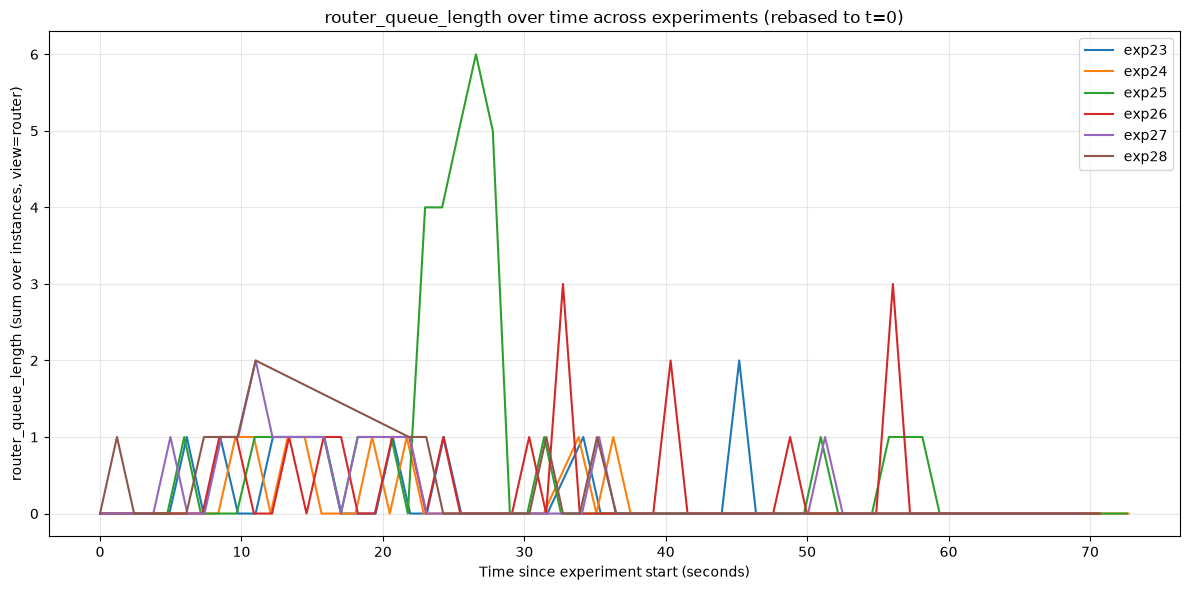

In [18]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS

print(experiments)
# ----------------------------

# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================

# --- Router metrics ---
metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"
# metric = "sidecar_workers_total"
# metric = "sidecar_workers_busy"
# metric = "sidecar_python_threads"

# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------

def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")

if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"

if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id, experiments_root="/data/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)

    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue

    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[23, 24, 25, 26, 27, 28]


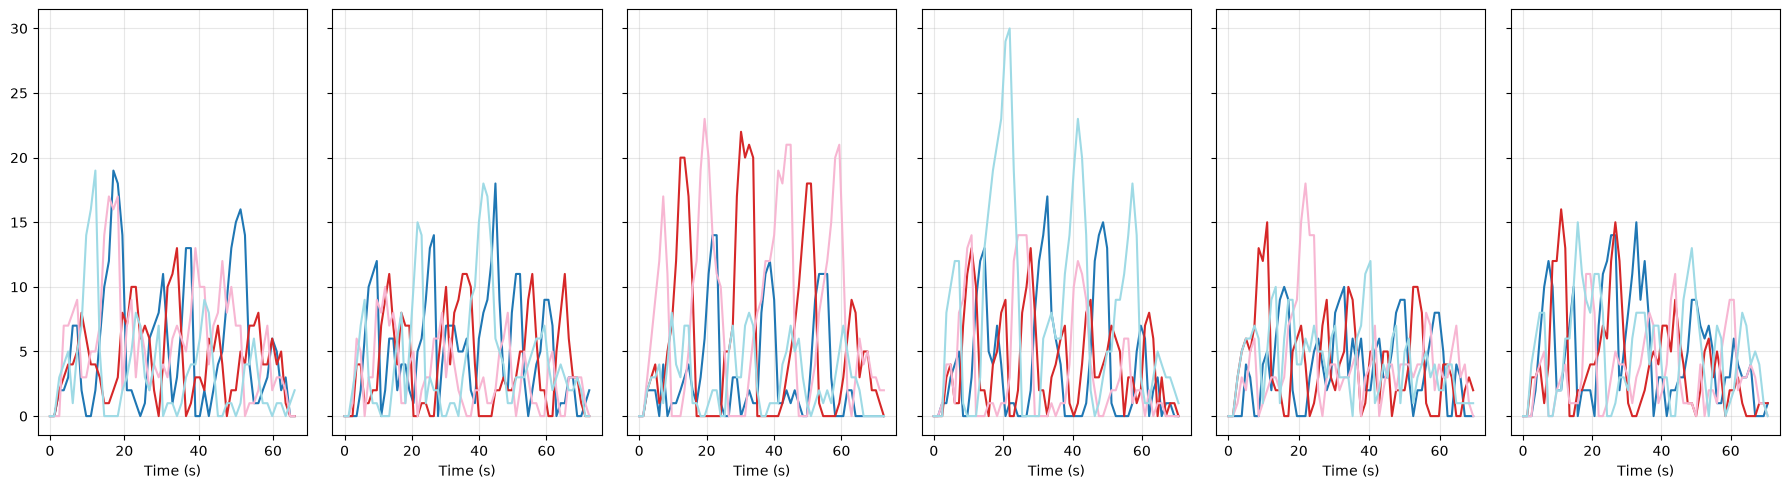

In [19]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = EXPERIMENTS
print(experiments)

# ============================================================
# Choose ONE metric (uncomment exactly one)
# ============================================================
# metric = "sidecar_queue_length"
metric = "requests_running"
# metric = "requests_waiting"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/data/experiments")
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]

# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = plt.colormaps["tab20"].resampled(len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
# plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)

plt.show()


## Prefix cache hit-rate: internal vs external

Compares per-`router_strategy` prefix-cache effectiveness, aggregated over the whole run
(vLLM rows on `:8200` only):

- **internal** = engine-local automatic prefix cache (`vllm:prefix_cache_*`) — KV blocks resident in *that* pod's HBM.
- **external** = KV connector / **Mooncake** shared store (`vllm:external_prefix_cache_*`) — cross-instance hits.

Whole-run hit rate is computed as `sum(hits_per_sec) / sum(queries_per_sec)` across all vLLM
instances/ticks (the ratio is meaningful even though the per-sec sums are proxies, not exact counts).
`none` is the baseline; compare the others against it.

In [20]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd


def _port_of_instance(inst):
    try:
        return int(str(inst).split(":")[1])
    except Exception:
        return None


def prefix_cache_summary(experiments=EXPERIMENTS, experiments_root=EXPERIMENTS_ROOT):
    rows = []
    for exp_id in experiments:
        label = STRATEGY_LABELS.get(exp_id, str(exp_id))
        prom = load_experiment_prom_samples(exp_id=exp_id, experiments_root=experiments_root)
        if prom.empty:
            print(f"[WARN] exp{exp_id} ({label}): no prom samples")
            continue
        # vLLM rows only (:8200) — prefix cache metrics live there
        df = prom[prom["instance"].map(_port_of_instance) == 8200]
        if df.empty:
            print(f"[WARN] exp{exp_id} ({label}): no :8200 rows")
            continue

        def _sum(col):
            return float(df[col].sum()) if col in df.columns else float("nan")

        ih, iq = _sum("prefix_cache_hits_per_sec"), _sum("prefix_cache_queries_per_sec")
        eh, eq = _sum("ext_prefix_cache_hits_per_sec"), _sum("ext_prefix_cache_queries_per_sec")
        rows.append({
            "exp": exp_id,
            "strategy": label,
            "internal_hit_rate": (ih / iq) if iq > 0 else float("nan"),
            "external_hit_rate": (eh / eq) if eq > 0 else float("nan"),
            "internal_queries_sum": iq,
            "external_queries_sum": eq,
            "prompt_tokens_cached_rate_sum": _sum("prompt_tokens_cached_per_sec"),
        })
    return pd.DataFrame(rows).set_index("strategy")


cache_cmp = prefix_cache_summary()
cache_cmp

,exp,internal_hit_rate,external_hit_rate,internal_queries_sum,external_queries_sum,prompt_tokens_cached_rate_sum
strategy,,,,,,
none,23,0.969386,NaN,7.361568e+06,0.0,7.141947e+06
prefix,24,0.969056,NaN,7.487454e+06,0.0,7.253351e+06
affinity (hard),25,0.981566,NaN,7.317401e+06,0.0,6.996957e+06
both (hard),26,0.978223,NaN,6.884901e+06,0.0,6.948893e+06
affinity (soft),27,0.972391,NaN,7.565587e+06,0.0,7.235007e+06
both (soft),28,0.971203,NaN,7.426275e+06,0.0,7.260116e+06


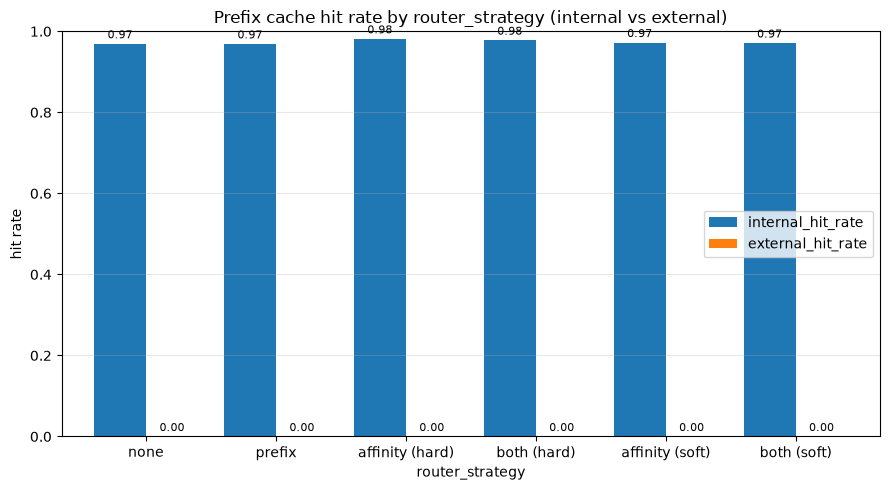

In [21]:
import matplotlib.pyplot as plt

# Bar chart: internal vs external prefix-cache hit rate per strategy.
ax = cache_cmp[["internal_hit_rate", "external_hit_rate"]].plot(
    kind="bar", figsize=(9, 5), width=0.8
)
ax.set_ylabel("hit rate")
ax.set_xlabel("router_strategy")
ax.set_title("Prefix cache hit rate by router_strategy (internal vs external)")
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y", alpha=0.3)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
plt.xticks(rotation=0)
plt.legend(title=None)
plt.tight_layout()

## Router KV-awareness (from logs.json, router.log fallback)

The vLLM cache metrics can't separate strategies when all traffic lands on one pod.
The **router's own decisions** can. These now live directly in `logs.json` as
per-request `endpoint_id`, `kv_hit`, and `matched_tokens` (written by
`router_log_collector` and the end-of-run join). For older runs without those
fields we fall back to parsing the router stdout line
`[PullRouter] chosen endpoint=... kv_hits=[(block, matched_tokens), ...]`.

This section reads `logs.json` (preferred) or `vllm-logs/router-service-*/router.log`
per experiment and reports:
- **endpoint distribution** — how traffic spread across vLLM pods,
- **frac_kv_hit** — fraction of requests where the router found KV-block hits (≈0 for `none`, >0 once `prefix`/`affinity`/`both` engage),
- **avg_matched_tokens** — average matched prefix tokens per hitting request.

If multiple `router-service-*` pods were captured (e.g. an old pod during redeploy), the
**freshest** pod (latest first-timestamp) is used to avoid cross-run contamination.

In [22]:
import re, json
from pathlib import Path
from collections import Counter
import pandas as pd

_ROUTER_LINE = re.compile(r"chosen endpoint=(?P<ep>\S+?):.*?kv_hits=\[(?P<kv>.*)\]\s*$")


def _router_log_first_ts(path):
    try:
        with open(path, errors="ignore") as f:
            for line in f:
                line = line.strip()
                if line:
                    return line.split(" ", 1)[0]
    except Exception:
        pass
    return ""


def parse_logs_json_kv(exp_id, experiments_root=EXPERIMENTS_ROOT):
    """Preferred path: read endpoint + KV fields straight from logs.json
    (written by router_log_collector + end-of-run join). Returns None when the
    enriched fields are absent, so the caller can fall back to the router.log regex.
    """
    logs_json = Path(experiments_root) / str(exp_id) / "logs.json"
    if not logs_json.is_file():
        return None
    eps = Counter()
    routed = hit_reqs = matched_tot = 0
    saw_kv = False
    for line in open(logs_json, errors="ignore"):
        line = line.strip()
        if not line:
            continue
        try:
            r = json.loads(line)
        except Exception:
            continue
        ep = r.get("endpoint_id")
        if not ep:
            continue
        routed += 1
        eps[ep] += 1
        if "kv_hit" in r:
            saw_kv = True
            if r.get("kv_hit"):
                hit_reqs += 1
                matched_tot += int(r.get("matched_tokens", 0) or 0)
    if routed == 0 or not saw_kv:
        return None
    return {
        "strategy": STRATEGY_LABELS.get(exp_id, str(exp_id)),
        "routed": routed,
        "endpoints_used": len(eps),
        "frac_kv_hit": (hit_reqs / routed) if routed else float("nan"),
        "avg_matched_tokens": (matched_tot / hit_reqs) if hit_reqs else 0.0,
        "endpoint_dist": dict(eps),
        "router_pod": "logs.json",
    }


def parse_router_log(exp_id, experiments_root=EXPERIMENTS_ROOT):
    base = Path(experiments_root) / str(exp_id) / "vllm-logs"
    logs = list(base.glob("router-service-*/router.log"))
    if not logs:
        return None
    # Use the freshest router pod (latest first timestamp) to avoid stale-pod contamination.
    chosen = max(logs, key=_router_log_first_ts)

    eps = Counter()
    routed = hit_reqs = matched_tot = 0
    for line in open(chosen, errors="ignore"):
        m = _ROUTER_LINE.search(line)
        if not m:
            continue
        routed += 1
        eps[m.group("ep")] += 1
        kv = m.group("kv").strip()
        if kv:
            hit_reqs += 1
            matched_tot += sum(int(x) for x in re.findall(r",\s*(\d+)\)", kv))
    return {
        "strategy": STRATEGY_LABELS.get(exp_id, str(exp_id)),
        "routed": routed,
        "endpoints_used": len(eps),
        "frac_kv_hit": (hit_reqs / routed) if routed else float("nan"),
        "avg_matched_tokens": (matched_tot / hit_reqs) if hit_reqs else 0.0,
        "endpoint_dist": dict(eps),
        "router_pod": chosen.parent.name,
    }


_rows = []
for _e in EXPERIMENTS:
    _r = parse_logs_json_kv(_e) or parse_router_log(_e)
    if _r is None:
        print(f"[WARN] exp{_e}: no logs.json kv fields or router.log found")
        continue
    _rows.append(_r)

router_kv = pd.DataFrame(_rows).set_index("strategy")
router_kv

,routed,endpoints_used,frac_kv_hit,avg_matched_tokens,endpoint_dist,router_pod
strategy,,,,,,
none,350,4,0.697143,512.000000,"{'vllm-minimax-m2-c7d5b98d8-77q4n': 97, 'vllm-...",logs.json
prefix,350,4,0.951429,1951.903904,"{'vllm-minimax-m2-c7d5b98d8-wwz4n': 76, 'vllm-...",logs.json
affinity (hard),350,4,0.974286,1152.000000,"{'vllm-minimax-m2-c7d5b98d8-hx2bh': 66, 'vllm-...",logs.json
both (hard),350,4,0.965714,2435.786982,"{'vllm-minimax-m2-c7d5b98d8-s79cz': 75, 'vllm-...",logs.json
affinity (soft),350,4,0.962857,450.089021,"{'vllm-minimax-m2-c7d5b98d8-z6z5v': 84, 'vllm-...",logs.json
both (soft),350,4,0.962857,1280.000000,"{'vllm-minimax-m2-c7d5b98d8-v86x2': 79, 'vllm-...",logs.json


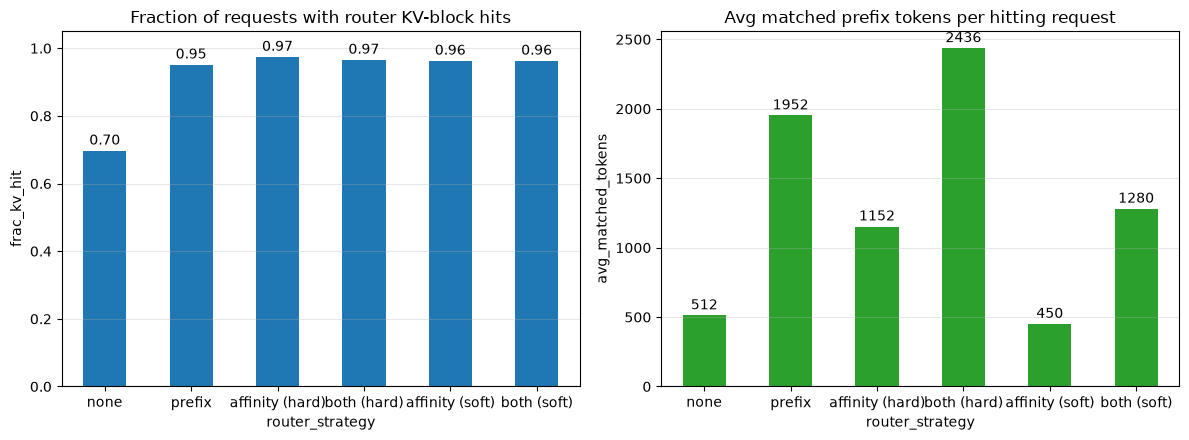

In [23]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

router_kv["frac_kv_hit"].plot(kind="bar", ax=ax1, color="tab:blue")
ax1.set_title("Fraction of requests with router KV-block hits")
ax1.set_ylabel("frac_kv_hit")
ax1.set_ylim(0, 1.05)
ax1.grid(True, axis="y", alpha=0.3)
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.2f", padding=2)

router_kv["avg_matched_tokens"].plot(kind="bar", ax=ax2, color="tab:green")
ax2.set_title("Avg matched prefix tokens per hitting request")
ax2.set_ylabel("avg_matched_tokens")
ax2.grid(True, axis="y", alpha=0.3)
for c in ax2.containers:
    ax2.bar_label(c, fmt="%.0f", padding=2)

for ax in (ax1, ax2):
    ax.set_xlabel("router_strategy")
    plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()

## Conversation affinity (stickiness)

`frac_kv_hit` above is a *prefix-reuse* signal. With `ROUTER_MEASURE_PREFIX=on` the router now
computes it for **every** strategy (including `none`/`affinity`, where KV routing is off), so it
is no longer pinned to 0 for `affinity` — affinity earns real prefix hits by keeping a
conversation's turns on the same pod. The metric below isolates affinity's *direct* objective —
**conversation stickiness**: keeping every turn of a multi-turn conversation on the same pod so
its growing KV stays warm.

We measure it from `logs.json` per request, grouping by `conversation_id` when
present, else by the router-provided `affinity_key` (so externally-observed runs
work too):

* `endpoint_id` per request (from the `router_log_collector` join); for older runs
  without it we fall back to mapping `reqhex -> pod` via the router stdout line
  `[PullRouter] chosen endpoint=<pod>: ['<reqhex>'] ...`
* the grouping key `conversation_id` (client runs) or `affinity_key` (router truth)

For each conversation with >= 2 turns we count the distinct pods its turns hit:

* **sticky_frac** = fraction of conversations whose turns ALL landed on one pod (1.0 = perfect affinity)
* **avg_distinct_pods** = mean distinct pods per conversation (1.0 = perfectly pinned; ~N_pods = fully scattered)

Note: this sweep includes both `AFFINITY_MODE = hard` (exp 25/26, a time-bounded pin) and
`AFFINITY_MODE = soft` (exp 27/28, a preference). Under oversubscribed load the soft preference
can be overridden by load balancing — expect high stickiness for the hard runs and only modest
stickiness for the soft runs.

In [24]:
import re, json
from pathlib import Path
from collections import defaultdict
import pandas as pd

_EP_IDS = re.compile(r"chosen endpoint=(?P<ep>\S+?):\s*\[(?P<ids>.*?)\]\s*kv_hits=")
_HEX = re.compile(r"[0-9a-f]{32}")


def _req_to_endpoint(router_log):
    """reqhex -> endpoint(pod) from a router.log's [PullRouter] chosen-endpoint lines."""
    req2ep = {}
    for line in open(router_log, errors="ignore"):
        m = _EP_IDS.search(line)
        if not m:
            continue
        ep = m.group("ep")
        for h in _HEX.findall(m.group("ids")):
            req2ep[h] = ep
    return req2ep


def conversation_affinity(exp_id, experiments_root=EXPERIMENTS_ROOT):
    base = Path(experiments_root) / str(exp_id)
    logs_json = base / "logs.json"
    if not logs_json.is_file():
        return None

    # Preferred: endpoint_id straight from logs.json (router_log_collector join).
    # Fallback: map req hex -> pod via router.log when endpoint_id is absent.
    rows = []
    need_router_map = False
    for line in open(logs_json, errors="ignore"):
        line = line.strip()
        if not line:
            continue
        try:
            r = json.loads(line)
        except Exception:
            continue
        rows.append(r)
        if not r.get("endpoint_id"):
            need_router_map = True

    req2ep = {}
    router_pod = "logs.json"
    rlogs = list((base / "vllm-logs").glob("router-service-*/router.log"))
    if rlogs:
        chosen = max(rlogs, key=_router_log_first_ts)  # freshest router pod
        router_pod = chosen.parent.name
        if need_router_map:
            req2ep = _req_to_endpoint(chosen)

    conv = defaultdict(list)  # group key (conversation_id|affinity_key) -> [pod per turn]
    for r in rows:
        ep = r.get("endpoint_id")
        if not ep:
            h = _HEX.search(str(r.get("req_id", "")))
            ep = req2ep.get(h.group(0)) if h else None
        if ep is None:
            continue
        group = r.get("conversation_id")
        if group is None:
            group = r.get("affinity_key")
        if group is not None:
            conv[group].append(ep)

    multi = [v for v in conv.values() if len(v) >= 2]
    distinct = [len(set(v)) for v in multi]
    sticky = sum(1 for d in distinct if d == 1)
    return {
        "strategy": STRATEGY_LABELS.get(exp_id, str(exp_id)),
        "mapped_convs": len(conv),
        "multiturn_convs": len(multi),
        "sticky_frac": (sticky / len(multi)) if multi else float("nan"),
        "avg_distinct_pods": (sum(distinct) / len(distinct)) if distinct else float("nan"),
        "router_pod": router_pod,
    }


_rows = []
for _e in EXPERIMENTS:
    _r = conversation_affinity(_e)
    if _r is None:
        print(f"[WARN] exp{_e}: no logs.json found")
        continue
    _rows.append(_r)

conv_affinity = pd.DataFrame(_rows).set_index("strategy")
conv_affinity

,mapped_convs,multiturn_convs,sticky_frac,avg_distinct_pods,router_pod
strategy,,,,,
none,100,100,0.10,2.37,router-service-b8c7d6c54-lb45j
prefix,100,100,0.08,2.32,router-service-57976885d8-wxg2w
affinity (hard),100,100,0.95,1.05,router-service-7c7b4ff57c-mlw6v
both (hard),100,100,1.00,1.00,router-service-69856866fb-sct5z
affinity (soft),100,100,0.15,2.29,router-service-57b8cf99b-mfvcp
both (soft),100,100,0.11,2.32,router-service-69498bd88f-7jn8c


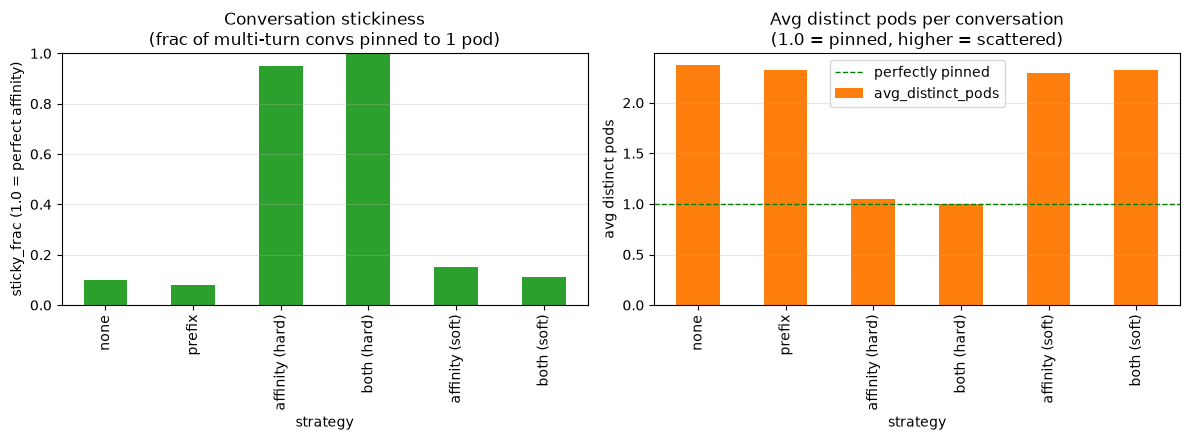

In [25]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

conv_affinity["sticky_frac"].plot(kind="bar", ax=ax1, color="tab:green")
ax1.set_title("Conversation stickiness\n(frac of multi-turn convs pinned to 1 pod)")
ax1.set_ylabel("sticky_frac (1.0 = perfect affinity)")
ax1.set_ylim(0, 1)
ax1.grid(axis="y", alpha=0.3)

conv_affinity["avg_distinct_pods"].plot(kind="bar", ax=ax2, color="tab:orange")
ax2.axhline(1.0, color="green", ls="--", lw=1, label="perfectly pinned")
ax2.set_title("Avg distinct pods per conversation\n(1.0 = pinned, higher = scattered)")
ax2.set_ylabel("avg distinct pods")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Combined summary — hard-affinity sweep (exp 10-13)

One table per strategy joining the three signals:

* **load balance** — min/max pod share of dispatches (`balance_ratio` near 1.0 = even split across the 3 pods),
* **frac_kv_hit** — prefix-cache reuse (>0 for `prefix`/`both`),
* **sticky_frac** / **avg_distinct_pods** — conversation affinity (1.0 / 1.0 = every multi-turn conversation pinned to one pod).

Expectation: `affinity (hard)` and `both (hard)` reach `sticky_frac ~ 1.0` *without* collapsing load to a single pod; `both` additionally keeps `frac_kv_hit > 0`.

In [26]:
import pandas as pd

# Reuses router_kv (KV-awareness cell) and conv_affinity (stickiness cell).
def _balance(dist):
    vals = list(dist.values())
    if not vals:
        return float("nan")
    return min(vals) / max(vals)

_kv = router_kv.copy()
_kv["pods_used"] = _kv["endpoint_dist"].apply(len)
_kv["balance_ratio"] = _kv["endpoint_dist"].apply(_balance).round(2)

summary = _kv[["routed", "pods_used", "balance_ratio", "frac_kv_hit", "avg_matched_tokens"]].join(
    conv_affinity[["multiturn_convs", "sticky_frac", "avg_distinct_pods"]]
)
summary["frac_kv_hit"] = summary["frac_kv_hit"].round(2)
summary["avg_matched_tokens"] = summary["avg_matched_tokens"].round(0)
summary["sticky_frac"] = summary["sticky_frac"].round(2)
summary["avg_distinct_pods"] = summary["avg_distinct_pods"].round(2)
summary

,routed,pods_used,balance_ratio,frac_kv_hit,avg_matched_tokens,multiturn_convs,sticky_frac,avg_distinct_pods
strategy,,,,,,,,
none,350,4,0.68,0.70,512.0,100,0.10,2.37
prefix,350,4,0.77,0.95,1952.0,100,0.08,2.32
affinity (hard),350,4,0.54,0.97,1152.0,100,0.95,1.05
both (hard),350,4,0.65,0.97,2436.0,100,1.00,1.00
affinity (soft),350,4,0.86,0.96,450.0,100,0.15,2.29
both (soft),350,4,0.79,0.96,1280.0,100,0.11,2.32
